In [1]:
historical_data = "raw_data.csv"

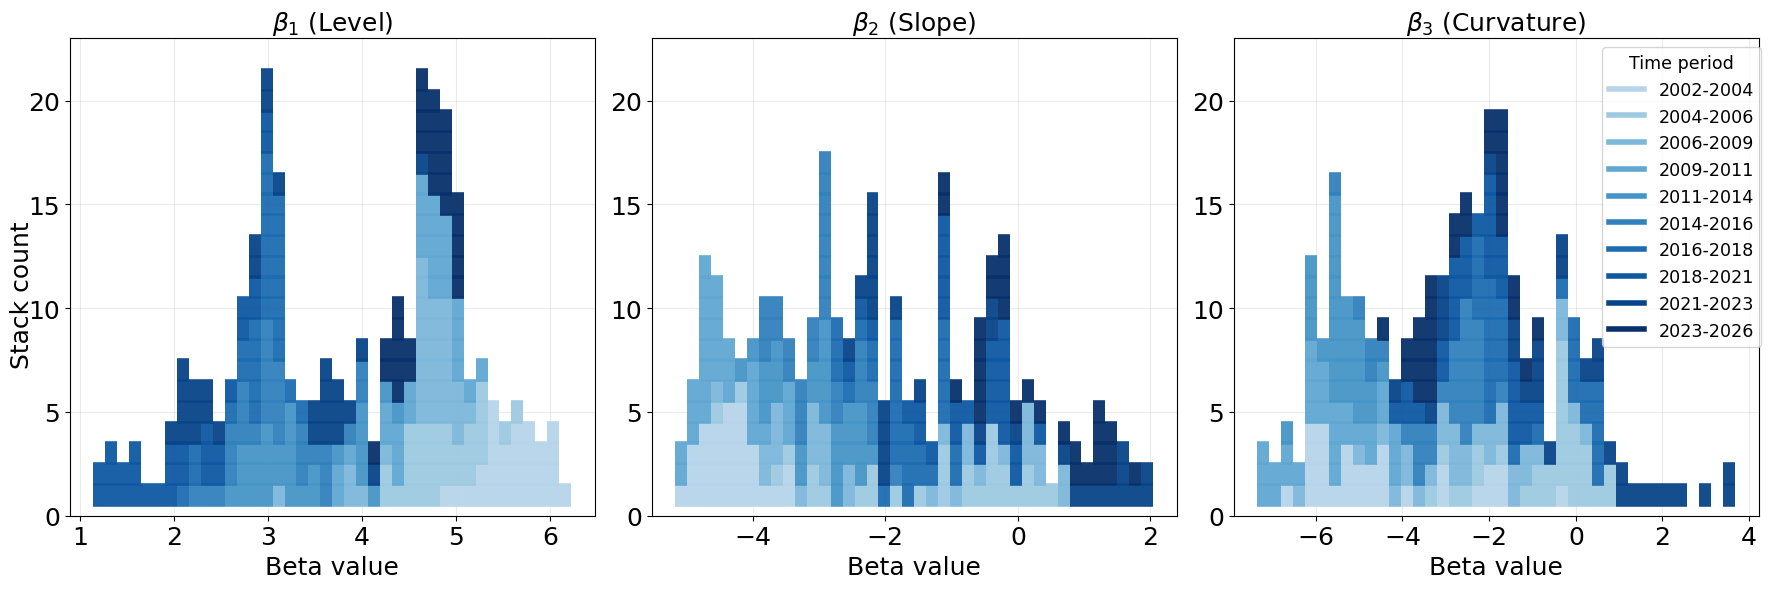

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

fs =  18

# ── Nelson-Siegel setup ─────────────────────────────────────────────────────
LAMBDA = 0.0609

HIST_MATS_YR = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])
HIST_MATS_MO = HIST_MATS_YR * 12

def ns_loadings(tau, lam):
    lt = lam * tau
    L1 = np.ones_like(lt)
    L2 = (1 - np.exp(-lt)) / lt
    L3 = L2 - np.exp(-lt)
    return np.column_stack([L1, L2, L3])

def fit_ns_ols(yields, tau, lam):
    X = ns_loadings(tau, lam)
    betas, _, _, _ = np.linalg.lstsq(X, yields, rcond=None)
    return betas

# ── Load data ───────────────────────────────────────────────────────────────
historical_data = historical_data

hist_cols = ['Yield_1M', 'Yield_3M', 'Yield_6M', 'Yield_1Y', 'Yield_2Y',
             'Yield_3Y', 'Yield_5Y', 'Yield_7Y', 'Yield_10Y', 'Yield_20Y', 'Yield_30Y']

hist = pd.read_csv(historical_data, parse_dates=['DATE'])
hist = hist.set_index('DATE')[hist_cols]
hist_monthly = hist.resample('ME').last().dropna()

# ── Fit NS ──────────────────────────────────────────────────────────────────
hist_betas = np.array([
    fit_ns_ols(row.values, HIST_MATS_MO, LAMBDA)
    for _, row in hist_monthly.iterrows()
])

dates = hist_monthly.index
n_obs = len(dates)

beta_labels = [
    r'$\beta_1$ (Level)',
    r'$\beta_2$ (Slope)',
    r'$\beta_3$ (Curvature)'
]

# ── Time coloring ───────────────────────────────────────────────────────────
n_periods = 10
period_edges = np.linspace(0, n_obs, n_periods + 1, dtype=int)
period_ids = np.zeros(n_obs, dtype=int)

for p in range(n_periods):
    period_ids[period_edges[p]:period_edges[p+1]] = p

colors = colors = plt.cm.Blues(np.linspace(0.3, 1, n_periods)) #plt.cm.rainbow(np.linspace(0, 1, n_periods))

period_labels = []
for p in range(n_periods):
    start = dates[period_edges[p]]
    end = dates[period_edges[p+1]-1]
    #period_labels.append(f"{start.strftime('%Y-%m')} to {end.strftime('%Y-%m')}")
    period_labels.append(
    f"{start.year}-{end.year}"
)

# ── Compute GLOBAL Y max only ────────────────────────────────────────────────
n_bins = 40
global_max_stack = 0

for i in range(3):
    vals = hist_betas[:, i]
    
    # IMPORTANT: each plot keeps its own x-range → use local binning
    vmin, vmax = vals.min(), vals.max()
    bin_edges = np.linspace(vmin, vmax, n_bins + 1)
    
    bin_idx = np.digitize(vals, bin_edges) - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)

    for b in range(n_bins):
        count = np.sum(bin_idx == b)
        global_max_stack = max(global_max_stack, count)

# ── Plot function ───────────────────────────────────────────────────────────
def stacked_bin_bars(ax, values, period_ids, colors, ymax):
    vmin, vmax = values.min(), values.max()
    bin_edges = np.linspace(vmin, vmax, n_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width = bin_edges[1] - bin_edges[0]

    bin_idx = np.digitize(values, bin_edges) - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)

    for b in range(n_bins):
        idx = np.where(bin_idx == b)[0]
        if len(idx) == 0:
            continue

        idx = idx[np.argsort(idx)]

        for stack_level, obs_idx in enumerate(idx, start=1):
            x_center = bin_centers[b]

            ax.hlines(
                y=stack_level,
                xmin=x_center - 0.5 * bin_width,
                xmax=x_center + 0.5 * bin_width,
                color=colors[period_ids[obs_idx]],
                linewidth=17,
                alpha=0.95
            )

    ax.set_ylim(0, ymax)

    ax.grid(True, alpha=0.25)

# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.supylabel("Stack count", fontsize=fs)

for i, ax in enumerate(axes):
    stacked_bin_bars(
        ax=ax,
        values=hist_betas[:, i],
        period_ids=period_ids,
        colors=colors,
        ymax=global_max_stack + 2
    )
    ax.set_title(beta_labels[i], fontsize=fs)
    ax.set_xlabel("Beta value", fontsize=fs)
    ax.tick_params(axis='both', labelsize=fs)

# Legend
handles = [plt.Line2D([0], [0], color=colors[p], lw=4) for p in range(n_periods)]
axes[2].legend(handles, period_labels, title="Time period", title_fontsize=fs*0.7,
               loc='upper right', bbox_to_anchor=(1.02, 1.0), fontsize=fs*0.7)

plt.tight_layout()
plt.show()